Add git location + imports

In [4]:
import os
print(os.getcwd())
import sys
sys.path.append('/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL') # change to git location

/media/chronos/Storage/natalie/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main


In [2]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np
from useful_functions import save_normalized, plot_loss_curves

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Preprocessing - normalization

In [ ]:
with open('fsm_all_images.txt', 'r') as f:
    fsm_files = [line.strip() for line in f if line.strip()]
for file_path in fsm_files:
    save_normalized(file_path)

#### **training**

Split data to train and test

In [ ]:
# Load file paths from the txt file (relative paths)
with open('../../fsmt1_short.txt', 'r') as f:
    fsm_files = [line.strip() for line in f if line.strip()]

# split
train_files, test_files = train_test_split(
    fsm_files,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"Number of files: {len(fsm_files)}")
print(f"Train: {len(train_files)}, Test: {len(test_files)}")

with open("train_files.txt", "w") as f:
    for line in train_files:
        f.write(f"{line}\n")  

with open("test_files.txt", "w") as f:
    for line in test_files:
        f.write(f"{line}\n")      

Train

## Model Training Overview

We explored multiple model architectures and loss functions to optimize registration quality. Below are the training configurations that were evaluated but not shown:

### 1. **MSE Loss**
- **Basic model**  
  Standard architecture trained with mean squared error (MSE) loss.
- **Self-attention bottleneck**  
  Incorporates self-attention in the bottleneck region.
- **Spatial attention skip connections**  
  Adds spatial attention mechanisms to the skip connections.
- **Combined attention**  
  Integrates both self-attention (bottleneck) and spatial attention (skip connections).

> **All MSE loss models above were trained with and without cyclic learning rate scheduling.**

---

### 2. **SSIM Loss**
- **Basic model**  
  Standard architecture trained with structural similarity index (SSIM) loss.
- **Combined attention**  
  Integrates both self-attention and spatial attention.

> **Both SSIM loss models were trained with and without cyclic learning rate scheduling.**

---

### 3. **SSIM + MSE Loss (with Cyclic Learning Rate)**
- **Basic model**  
  Standard architecture trained with a combined SSIM and MSE loss.
- **Combined attention**  
  Includes both attention mechanisms.

> All models in this group used a cyclic learning rate schedule.

---

This design enables a systematic assessment of attention mechanisms, loss functions, and learning rate scheduling on registration performance.


In [ ]:
%run -i ../scripts/train.py --img-list train_files.txt --batch-size 2 --epochs 25 --image-loss ssim

Show training results

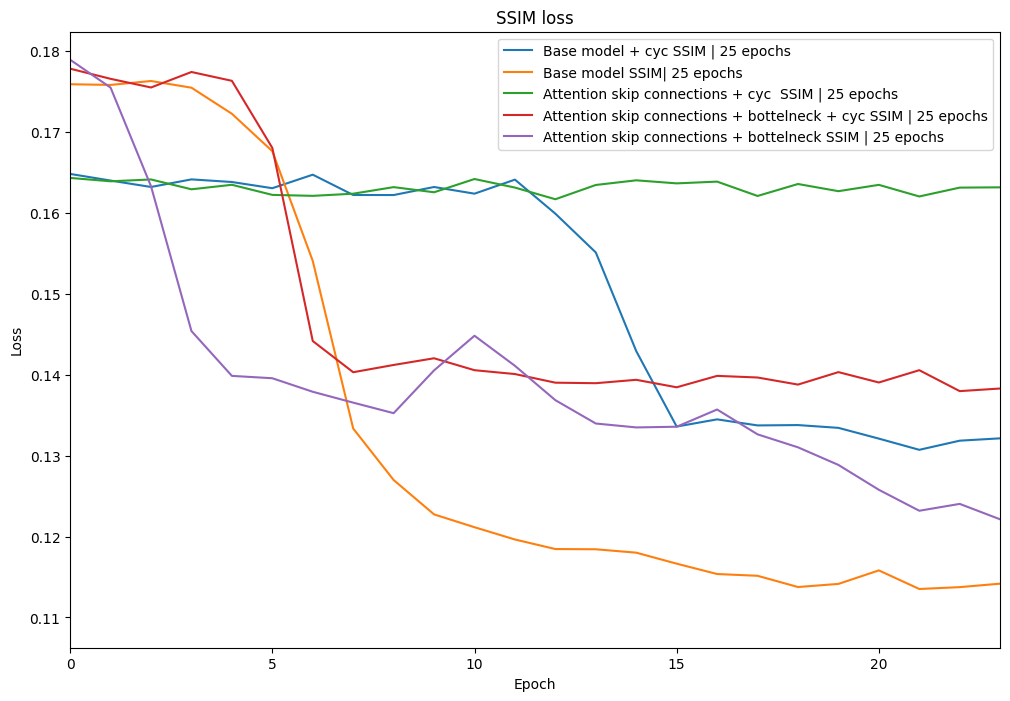

<Figure size 1200x600 with 0 Axes>

In [10]:
# with SSIM Loss

file_paths = [
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/SSIM_norm_loss/loss_history_SSIM_b2_norm.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/SSIM_norm_loss/loss_history_base_ssim_no_cyc.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/SSIM_norm_loss/loss_history_skip_attention_SSIM_b2_norm.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/SSIM_norm_loss/loss_history__att_ssim_2b_cyc.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/SSIM_norm_loss/loss_history_attentions_ssim_ne_cyc.txt',
]

labels = [
    "Base model + cyc SSIM | 25 epochs",
    "Base model SSIM| 25 epochs",
    "Attention skip connections + cyc  SSIM | 25 epochs",
    "Attention skip connections + bottelneck + cyc SSIM | 25 epochs",
    "Attention skip connections + bottelneck SSIM | 25 epochs"

]

plot_loss_curves(file_paths, labels, title = "SSIM loss")

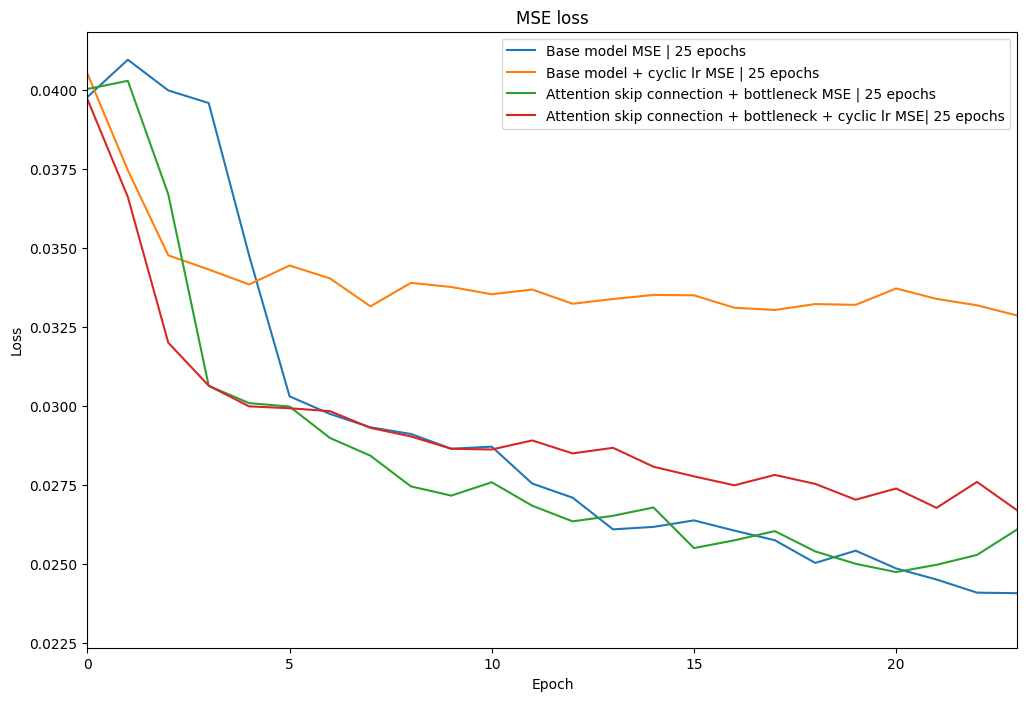

<Figure size 1200x600 with 0 Axes>

In [17]:
# with MSE Loss

file_paths_MSE = [
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/MSE_norm_loss/loss_history_baseline_no_cyc_mse.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/MSE_norm_loss/loss_history_50_epochs_base_normlized_cyc.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/MSE_norm_loss/loss_history_attentions_MSE_no_cyc_b2.txt',
    '/home/natalie/UserSpace/HW/DEEP_LEARN_PROJECT/voxelmorph_extension_DL/main/models/MSE_norm_loss/loss_history_0050_att_cyc_norm_b2_mse.txt'
]

labels_MSE = [
    "Base model MSE | 25 epochs",
    "Base model + cyclic lr MSE | 25 epochs",
    "Attention skip connection + bottleneck MSE | 25 epochs",
    "Attention skip connection + bottleneck + cyclic lr MSE| 25 epochs"

]

plot_loss_curves(file_paths_MSE, labels_MSE, title = "MSE loss")